# Fourier Portfolio Construction

In [2]:
import sys, os, inspect, shutil, importlib
sys.path.insert(0, '/var/www/python/Qingcheng/Fourier')
sys.path.append('/var/www/python/Prod/nighthawk/')
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from nighthawk.util import bigquery_functions, connections, sql_functions, dataframe_functions
from nighthawk.data.pipeline.var_handler import loadwindgen_vh, wind_vh
from nighthawk.data.pipeline.common_functions import wind
from google.cloud import bigquery
import utils_fourier.ve_portfolio_constructor_fourier as ve_portfolio_constructor_fourier

from common_functions import get_scale_factor


In [127]:
# --- helper functions (from production 04_portfolio_construction.py) ---
def fourier_port(link, start_date, end_date, saved):
    def hourly_lwg_cut(df, bid_date):
        total_lwg_df = loadwindgen_vh.get_data_and_mapping_for_total_lwg(
            [636], "SPP", start_dt=bid_date, end_dt=bid_date, n_day_pctl_flag=False)[0]
        high_lwg_hr_lst = list(total_lwg_df.loc[total_lwg_df['spp_loadwindgen_forecast_f'] >= 55000, 'hr'].unique())
        print(f"lwg cut hours: {high_lwg_hr_lst}")
        if len(high_lwg_hr_lst) > 0:
            df['bid_mw'] = np.where(df['hr'].isin(high_lwg_hr_lst), 0, df['bid_mw'])
        return df

    def apply_price_filter(df):
        df['bid_price'] = np.where((df['incdec'] == 'Increment') & (df['bid_price'] < -100), -100, df['bid_price'])
        df['bid_price'] = np.where((df['incdec'] == 'Decrement') & (df['bid_price'] > 300), 300, df['bid_price'])
        return df[df['bid_price'] < 2000]

    def apply_mw_filter(df):
        return df[df['bid_mw'] >= 0.1]

    def portfolio_cut(portfolio, bid_date):
        portfolio = apply_price_filter(portfolio)
        portfolio = hourly_lwg_cut(portfolio, bid_date)
        portfolio = apply_mw_filter(portfolio)
        return portfolio

    # --- config ---
    opexchange    = 'SPP'
    run_number    = 1
    condition_label = 2  # 0=test, 1=holdout, 2=production
    valuationModel_label = ''
    nodeSelection_label  = 'Fourier'
    file_location_cloudserver = '/var/www/python/Qingcheng/temp_test_fourier/'
    os.makedirs(file_location_cloudserver + 'return_and_risk', exist_ok=True)
    os.makedirs(file_location_cloudserver + 'nodeSelection', exist_ok=True)
    conn = connections.get_sql_connection(database='temp')

    # --- segments (matches production) ---
    segments = pd.DataFrame({
        'quantile_DA': ['da_total_q95', 'da_total_q90', 'da_total_q80', 'da_total_q70',
                        'da_total_q60', 'da_total_q50', 'da_total_q40', 'da_total_q30',
                        'da_total_q20', 'da_total_q10', 'da_total_q5'],
        'decSegment': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
        'incSegment': [11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]})

    # --- load data ---
    df = pd.read_csv(f'/var/www/python/Qingcheng/WFiles/{link}.csv')
    df = df[df['dt'] >= start_date]
    df = df[df['dt'] <= end_date]  # test single date

    all_portfolios = []
    dates = sorted(df['dt'].unique())
    print(f'Running portfolio construction for {len(dates)} dates')

    try:
        for bid_date in dates:
            print(f'\n--- {bid_date} ---')
            try:
                # 1. Valuation model from CSV
                df_date = df[df['dt'] == bid_date].copy()
                df_date['node_num'] = df_date['node_num'].astype(int)
                df_date['dt']       = df_date['dt'].astype(str)
                df_date['hr']       = df_date['hr'].astype(int)
                total_col = [col for col in df_date.columns if
                            col.startswith('da_total_') or col.startswith('rt_total_')]
                valuationModel = df_date[['dt', 'hr', 'node_num'] + total_col].groupby(
                    ['dt', 'hr', 'node_num']).max().reset_index()

                # 2. Node selection
                nodeSelection = pd.read_sql(
                    f"SELECT * FROM Fourier_{opexchange}.nodeSelection WHERE dt = '{bid_date}' AND source = 'PCA'", conn)
                nodeSelection['dt']       = nodeSelection['dt'].astype(str)
                nodeSelection['node_num'] = nodeSelection['node_num'].astype(int)
                nodeSelection['nodeSelection'] = nodeSelection_label
                nodeSelection.to_csv(file_location_cloudserver + 'nodeSelection/' + bid_date + '.csv', index=False)

                # 3. Op_rate and ref price
                ve_port = ve_portfolio_constructor_fourier.VEPortfolioConstructorFourier(opexchange)
                valuationModel = ve_port.get_oprate_lmp_price_and_ref_value(valuationModel)
                for col in ['op_rate_inc_a', 'op_rate_dec_a', 'op_rate_inc_f', 'op_rate_dec_f', 'bid_ref_price', 'offer_ref_price']:
                    if col in valuationModel.columns:
                        valuationModel[col].fillna(value=valuationModel[col].mean(), inplace=True)

                # 4. Cumulative return and risk
                ve_port.calculate_cumulative_return_and_risk_for_one_day(
                    valuationModel,
                    save_cloudserver_location=file_location_cloudserver + 'return_and_risk/',
                    prediction='total', segments=segments, date=bid_date)

                # 5. Wind / LWG for constraints
                total_wind_df = wind_vh.get_data_and_mapping_for_baa_zonal_wind(
                    node_list=[636], opexchange='SPP',
                    start_dt=(pd.to_datetime(bid_date) - pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
                    end_dt=(pd.to_datetime(bid_date) + pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
                    var_spec=['f'], impute=True, ramp_flag=True, ramp_periods=[2])[0].rename(columns={
                        'e_spp_baa_zonal_wind_forecast_f': 'spp_wind_total_forecast_f',
                        'e_spp_baa_zonal_wind_actual_a': 'spp_wind_total_actual_a',
                        'BackwardRampNoSlope2_e_spp_baa_zonal_wind_forecast_f': 'BackwardRampNoSlope2_spp_wind_total_forecast_f',
                        'BackwardRampNoSlope2_e_spp_baa_zonal_wind_actual_a': 'BackwardRampNoSlope2_spp_wind_total_actual_a'})
                
                total_lwg_df = loadwindgen_vh.get_data_and_mapping_for_baa_zonal_lwg(
                    [636], "SPP",
                    start_dt=(pd.to_datetime(bid_date) - pd.to_timedelta('35D')).strftime('%Y-%m-%d'),
                    end_dt=(pd.to_datetime(bid_date) + pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
                    n_day_pctl_flag=True)[0].rename(columns={
                        'e_spp_baa_zonal_loadwindgen_forecast_f': 'spp_loadwindgen_forecast_f',
                        'e_spp_baa_zonal_loadwindgen_actual_a': 'spp_loadwindgen_actual_a',
                        'Perc_30D_e_spp_baa_zonal_loadwindgen_forecast_f': 'Perc_30D_spp_loadwindgen_forecast_f',
                        'Perc_30D_e_spp_baa_zonal_loadwindgen_actual_a': 'Perc_30D_spp_loadwindgen_actual_a'})

                constraints_option = ['v2', {
                    'max_mw_per_segment': 5, 'totalRiskAllowed': 10000, 'total_mw_limit': 20000,
                    'nodal_mw_limit': 700, 'nodal_hrly_mw_limit': 60, 'nodal_hrly_incdec_mw_limit': 40,
                    'totalCollateralAllowed': 700000, 'inc_upper_perc_limit': 0.7, 'dec_upper_perc_limit': 0.7,
                    'hrly_inc_mw_limit': 450,
                    'hrly_inc_upper_perc_limit_extreme_physical_condition': {
                        'BackwardRampNoSlope2_spp_wind_total_forecast_f': -3000,
                        'hrly_inc_upper_perc_limit': 0.1, 'physical_var_df': total_wind_df},
                    'hrly_dec_upper_perc_limit_extreme_physical_condition': {
                        'Perc_30D_spp_loadwindgen_forecast_f': 0.02, 'hrly_dec_upper_perc_limit': 0.2,
                        'physical_var_df': total_lwg_df},
                }]

                # 6. Portfolio construction (production params)
                para = {
                    'maxDecPrice': 300, 'minIncPrice': -75, 'PowerROC': 1,
                    'minExpectedProfit': 0.7, 'maximumROR': 3000, 'minimumROR': 250, 'maximumROC': 100,
                    'MinExpectedReturnOnCollateral': 0, 'maxSegmentNum': 8,
                    'objectiveFunction': 'expectedProfit',
                    'constraints_option': constraints_option, 'PortionOfFullRisk': 1,
                    'segments_clear_prob': pd.DataFrame(),
                    'data_location': file_location_cloudserver,
                    'nodeSelection_label': nodeSelection_label,
                    'valuationModel_label': valuationModel_label,
                    'condition_label': condition_label, 'cumulativeRisk_ceil': -0.1
                }
                portfolio = ve_port.get_daily_terence_portfolio(bid_date, **para)

                # 7. Cut
                portfolio = portfolio[portfolio['bid_mw'] > 0]
                portfolio = portfolio_cut(portfolio, bid_date)

                # 8. Scale (fixed scale only — no wind scaling for Fourier backtest)
                scale_factor = get_scale_factor(opexchange).values[0][0]
                portfolio['bid_mw'] = portfolio['bid_mw'] * scale_factor
                portfolio['run_number'] = run_number

                print(f'  {len(portfolio)} bids, {round(portfolio["bid_mw"].sum())} total MW')
                all_portfolios.append(portfolio)

            except Exception as e:
                import traceback
                print(f'  [SKIP] {bid_date}: {e}')
                traceback.print_exc()
                continue

    finally:
        shutil.rmtree(file_location_cloudserver, ignore_errors=True)
        print(f'Cleaned up {file_location_cloudserver}')

    # --- save ---
    if all_portfolios:
        final_portfolio = pd.concat(all_portfolios, ignore_index=True)
        save_path = f'/var/www/python/Qingcheng/WFiles/{saved}.csv'
        final_portfolio.to_csv(save_path, index=False)
        print(f'\nSaved {final_portfolio.shape} to {save_path}')
    else:
        print('No portfolios generated.')


In [ ]:
import sys, os, inspect, shutil, importlib
sys.path.insert(0, '/var/www/python/Qingcheng/Fourier')
sys.path.append('/var/www/python/Prod/nighthawk/')
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from nighthawk.util import bigquery_functions, connections, sql_functions, dataframe_functions
from nighthawk.data.pipeline.var_handler import loadwindgen_vh, wind_vh
from nighthawk.data.pipeline.common_functions import wind
from google.cloud import bigquery
import utils_fourier.ve_portfolio_constructor_fourier as ve_portfolio_constructor_fourier

from common_functions import get_scale_factor

# --- helper functions (from production 04_portfolio_construction.py) ---
def hourly_lwg_cut(df, bid_date):
    total_lwg_df = loadwindgen_vh.get_data_and_mapping_for_total_lwg(
        [636], "SPP", start_dt=bid_date, end_dt=bid_date, n_day_pctl_flag=False)[0]
    high_lwg_hr_lst = list(total_lwg_df.loc[total_lwg_df['spp_loadwindgen_forecast_f'] >= 55000, 'hr'].unique())
    print(f"lwg cut hours: {high_lwg_hr_lst}")
    if len(high_lwg_hr_lst) > 0:
        df['bid_mw'] = np.where(df['hr'].isin(high_lwg_hr_lst), 0, df['bid_mw'])
    return df

def apply_price_filter(df):
    df['bid_price'] = np.where((df['incdec'] == 'Increment') & (df['bid_price'] < -100), -100, df['bid_price'])
    df['bid_price'] = np.where((df['incdec'] == 'Decrement') & (df['bid_price'] > 300), 300, df['bid_price'])
    return df[df['bid_price'] < 2000]

def apply_mw_filter(df):
    return df[df['bid_mw'] >= 0.1]

def portfolio_cut(portfolio, bid_date):
    portfolio = apply_price_filter(portfolio)
    portfolio = hourly_lwg_cut(portfolio, bid_date)
    portfolio = apply_mw_filter(portfolio)
    return portfolio

# --- config ---
opexchange    = 'SPP'
run_number    = 1
condition_label = 2  # 0=test, 1=holdout, 2=production
valuationModel_label = ''
nodeSelection_label  = 'Fourier'
file_location_cloudserver = '/var/www/python/Qingcheng/temp_test_fourier/'
os.makedirs(file_location_cloudserver + 'return_and_risk', exist_ok=True)
os.makedirs(file_location_cloudserver + 'nodeSelection', exist_ok=True)
conn = connections.get_sql_connection(database='temp')

# --- segments (matches production) ---
segments = pd.DataFrame({
    'quantile_DA': ['da_total_q95', 'da_total_q90', 'da_total_q80', 'da_total_q70',
                    'da_total_q60', 'da_total_q50', 'da_total_q40', 'da_total_q30',
                    'da_total_q20', 'da_total_q10', 'da_total_q5'],
    'decSegment': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    'incSegment': [11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]})

# --- load data ---
df = pd.read_csv('/var/www/python/Qingcheng/WFiles/sppfourier_without_dayzer.csv')
# df = df[df['dt'] <= '2026-02-01']  # test single date

all_portfolios = []
dates = sorted(df['dt'].unique())
print(f'Running portfolio construction for {len(dates)} dates')

try:
    for bid_date in dates:
        print(f'\n--- {bid_date} ---')
        try:
            # 1. Valuation model from CSV
            df_date = df[df['dt'] == bid_date].copy()
            df_date['node_num'] = df_date['node_num'].astype(int)
            df_date['dt']       = df_date['dt'].astype(str)
            df_date['hr']       = df_date['hr'].astype(int)
            total_col = [col for col in df_date.columns if
                         col.startswith('da_total_') or col.startswith('rt_total_')]
            valuationModel = df_date[['dt', 'hr', 'node_num'] + total_col].groupby(
                ['dt', 'hr', 'node_num']).max().reset_index()

            # 2. Node selection
            nodeSelection = pd.read_sql(
                f"SELECT * FROM Fourier_{opexchange}.nodeSelection WHERE dt = '{bid_date}' AND source = 'PCA'", conn)
            nodeSelection['dt']       = nodeSelection['dt'].astype(str)
            nodeSelection['node_num'] = nodeSelection['node_num'].astype(int)
            nodeSelection['nodeSelection'] = nodeSelection_label
            nodeSelection.to_csv(file_location_cloudserver + 'nodeSelection/' + bid_date + '.csv', index=False)

            # 3. Op_rate and ref price
            ve_port = ve_portfolio_constructor_fourier.VEPortfolioConstructorFourier(opexchange)
            valuationModel = ve_port.get_oprate_lmp_price_and_ref_value(valuationModel)
            for col in ['op_rate_inc_a', 'op_rate_dec_a', 'op_rate_inc_f', 'op_rate_dec_f', 'bid_ref_price', 'offer_ref_price']:
                if col in valuationModel.columns:
                    valuationModel[col].fillna(value=valuationModel[col].mean(), inplace=True)

            # 4. Cumulative return and risk
            ve_port.calculate_cumulative_return_and_risk_for_one_day(
                valuationModel,
                save_cloudserver_location=file_location_cloudserver + 'return_and_risk/',
                prediction='total', segments=segments, date=bid_date)

            # 5. Wind / LWG for constraints
            total_wind_df = wind_vh.get_data_and_mapping_for_baa_zonal_wind(
                node_list=[636], opexchange='SPP',
                start_dt=(pd.to_datetime(bid_date) - pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
                end_dt=(pd.to_datetime(bid_date) + pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
                var_spec=['f'], impute=True, ramp_flag=True, ramp_periods=[2])[0].rename(columns={
                    'e_spp_baa_zonal_wind_forecast_f': 'spp_wind_total_forecast_f',
                    'e_spp_baa_zonal_wind_actual_a': 'spp_wind_total_actual_a',
                    'BackwardRampNoSlope2_e_spp_baa_zonal_wind_forecast_f': 'BackwardRampNoSlope2_spp_wind_total_forecast_f',
                    'BackwardRampNoSlope2_e_spp_baa_zonal_wind_actual_a': 'BackwardRampNoSlope2_spp_wind_total_actual_a'})
            
            total_lwg_df = loadwindgen_vh.get_data_and_mapping_for_baa_zonal_lwg(
                [636], "SPP",
                start_dt=(pd.to_datetime(bid_date) - pd.to_timedelta('35D')).strftime('%Y-%m-%d'),
                end_dt=(pd.to_datetime(bid_date) + pd.to_timedelta('1D')).strftime('%Y-%m-%d'),
                n_day_pctl_flag=True)[0].rename(columns={
                    'e_spp_baa_zonal_loadwindgen_forecast_f': 'spp_loadwindgen_forecast_f',
                    'e_spp_baa_zonal_loadwindgen_actual_a': 'spp_loadwindgen_actual_a',
                    'Perc_30D_e_spp_baa_zonal_loadwindgen_forecast_f': 'Perc_30D_spp_loadwindgen_forecast_f',
                    'Perc_30D_e_spp_baa_zonal_loadwindgen_actual_a': 'Perc_30D_spp_loadwindgen_actual_a'})

            constraints_option = ['v2', {
                'max_mw_per_segment': 5, 'totalRiskAllowed': 10000, 'total_mw_limit': 20000,
                'nodal_mw_limit': 700, 'nodal_hrly_mw_limit': 60, 'nodal_hrly_incdec_mw_limit': 40,
                'totalCollateralAllowed': 700000, 'inc_upper_perc_limit': 0.7, 'dec_upper_perc_limit': 0.7,
                'hrly_inc_mw_limit': 450,
                'hrly_inc_upper_perc_limit_extreme_physical_condition': {
                    'BackwardRampNoSlope2_spp_wind_total_forecast_f': -3000,
                    'hrly_inc_upper_perc_limit': 0.1, 'physical_var_df': total_wind_df},
                'hrly_dec_upper_perc_limit_extreme_physical_condition': {
                    'Perc_30D_spp_loadwindgen_forecast_f': 0.02, 'hrly_dec_upper_perc_limit': 0.2,
                    'physical_var_df': total_lwg_df},
            }]

            # 6. Portfolio construction (production params)
            para = {
                'maxDecPrice': 300, 'minIncPrice': -75, 'PowerROC': 1,
                'minExpectedProfit': 0.7, 'maximumROR': 3000, 'minimumROR': 250, 'maximumROC': 100,
                'MinExpectedReturnOnCollateral': 0, 'maxSegmentNum': 8,
                'objectiveFunction': 'expectedProfit',
                'constraints_option': constraints_option, 'PortionOfFullRisk': 1,
                'segments_clear_prob': pd.DataFrame(),
                'data_location': file_location_cloudserver,
                'nodeSelection_label': nodeSelection_label,
                'valuationModel_label': valuationModel_label,
                'condition_label': condition_label, 'cumulativeRisk_ceil': -0.1
            }
            portfolio = ve_port.get_daily_terence_portfolio(bid_date, **para)

            # 7. Cut
            portfolio = portfolio[portfolio['bid_mw'] > 0]
            portfolio = portfolio_cut(portfolio, bid_date)

            # 8. Scale (fixed scale only — no wind scaling for Fourier backtest)
            scale_factor = get_scale_factor(opexchange).values[0][0]
            portfolio['bid_mw'] = portfolio['bid_mw'] * scale_factor
            portfolio['run_number'] = run_number

            print(f'  {len(portfolio)} bids, {round(portfolio["bid_mw"].sum())} total MW')
            all_portfolios.append(portfolio)

        except Exception as e:
            import traceback
            print(f'  [SKIP] {bid_date}: {e}')
            traceback.print_exc()
            continue

finally:
    shutil.rmtree(file_location_cloudserver, ignore_errors=True)
    print(f'Cleaned up {file_location_cloudserver}')

# --- save ---
if all_portfolios:
    final_portfolio = pd.concat(all_portfolios, ignore_index=True)
    save_path = '/var/www/python/Qingcheng/WFiles/fourier_port_without_dayzer.csv'
    final_portfolio.to_csv(save_path, index=False)
    print(f'\nSaved {final_portfolio.shape} to {save_path}')
else:
    print('No portfolios generated.')


# Convert Bids table to pnl

In [22]:
import sys
sys.path.append("/var/www/python/Prod/nighthawk/")
from nighthawk.data.product.ve import DailyBidsManager
from nighthawk.data.network.node import Node
import numpy as np 
import pandas as pd

def simulate_total_ftp(table):

    MARKET_CONFIG = {
    'SPP': {
        'load_table': 'spp_physical.spp_latest_load_forecast',
        'wind_table': 'spp_physical.spp_latest_wind_forecast',
        'inc_op_rate': 2.0,
        'dec_op_rate': 0.1
    },
    'PJM': {
        'load_table': '',
        'wind_table': '',
        'inc_op_rate': 0.0,
        'dec_op_rate': 0.0
    },
    'MISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'ERCOT': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'NYISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
}
    
    m_cfg = MARKET_CONFIG['SPP']
    df_bids = table

    # 3. Prices
    node_list = df_bids['node_num'].unique().tolist()

    node_obj = Node(node_nums=node_list, market='SPP')
    date_start = table.dt.min()
    date_end = table.dt.max()
    print(date_start,date_end)

    df_prices = node_obj.get_price(
        start_dt=date_start,
        end_dt=date_end,
        component=['LMP','MCC'],
        type=['DA', 'RT'],
        granularity='hourly'
    )

    if not df_prices.empty:
        df_prices.rename(columns={'da_total': 'dalmp', 'rt_total': 'rtlmp'}, inplace=True)
        df_prices['hr'] = df_prices['hr'].astype(int)
        df_prices['node_num'] = df_prices['node_num'].astype(int)
        df_sim = pd.merge(df_bids, df_prices, left_on=['dt', 'hr', 'node_num'],
                            right_on=['dt', 'hr', 'node_num'], how='left')
    else:
        df_sim['dalmp'] = np.nan
        df_sim['rtlmp'] = np.nan

    # 4. Calculations (Preserved as per instruction)
    inc_op_rate = m_cfg['inc_op_rate']
    dec_op_rate = m_cfg['dec_op_rate']

    conditions_clear = [
        (df_sim['incdec'] == 'Decrement') & (df_sim['bid_price'] >= df_sim['dalmp']),
        (df_sim['incdec'] == 'Increment') & (df_sim['bid_price'] <= df_sim['dalmp'])
    ]
    df_sim['is_cleared'] = np.select(conditions_clear, [True, True], default=False)
    df_sim.loc[df_sim['dalmp'].isna(), 'is_cleared'] = False
    df_sim['clear_mw'] = np.where(df_sim['is_cleared'], df_sim['bid_mw'], 0.0)

    # DA & RT Cash
    df_sim['total_da_val'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['dalmp'], df_sim['clear_mw'] * df_sim['dalmp'])
    df_sim['total_da_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_val'])
    df_sim['total_da_slack'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['da_slack'], df_sim['clear_mw'] * df_sim['da_slack'])
    df_sim['total_da_slack_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_slack'])
    df_sim['total_da_congestional'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['da_congestion_x'], df_sim['clear_mw'] * df_sim['da_congestion_x'])
    df_sim['total_da_cong_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_congestional'])

    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rtlmp'], -1 * df_sim['clear_mw'] * df_sim['rtlmp'])
    df_sim['total_rt_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)
    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rt_slack'], -1 * df_sim['clear_mw'] * df_sim['rt_slack'])
    df_sim['total_rt_slack_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)
    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rt_congestion_y'], -1 * df_sim['clear_mw'] * df_sim['rt_congestion_y'])
    df_sim['total_rt_cong_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)

    # RSG
    rsg_cost = np.where(df_sim['incdec'] == 'Increment', df_sim['clear_mw'] * inc_op_rate, df_sim['clear_mw'] * dec_op_rate)
    df_sim['op_rate_val'] = np.where(df_sim['rtlmp'].isna(), 0, -1 * rsg_cost)

    # Totals
    df_sim['gross_pnl'] = df_sim['total_da_elapsed'] + df_sim['total_rt_elapsed']
    df_sim['net_pnl'] = df_sim['gross_pnl'] + df_sim['op_rate_val']
    df_sim['slack_pnl'] = df_sim['total_da_slack_elapsed']+df_sim['total_rt_slack_elapsed']
    df_sim['cong_pnl'] = df_sim['total_da_cong_elapsed']+df_sim['total_rt_cong_elapsed']
    
    df_sim.fillna(0, inplace=True)
    df_sim.sort_values(by=['gross_pnl'],ascending=True,inplace=True)
    # 5. Aggregation & Data Return

    agg_dict = {
        'bid_mw': 'sum', 'clear_mw': 'sum',
        'total_da_val': 'sum', 'total_da_elapsed': 'sum', 'total_rt_elapsed': 'sum', 'op_rate_val': 'sum',
        'gross_pnl': 'sum', 'net_pnl': 'sum'
    }
    renamer = {
        'bid_mw': 'BidMW', 'clear_mw': 'ClearMW',
        'total_da_val': 'TotalDA$', 'total_da_elapsed': 'TotalDAElapsed$',
        'total_rt_elapsed': 'TotalRTElapsed$', 'op_rate_val': 'OpRate$',
        'gross_pnl': 'Gross$', 'net_pnl': 'Net$'
    }

    # A. Overall Summary
    summ_data = df_sim.agg(agg_dict).to_frame().T.rename(columns=renamer).to_dict('records')
    return df_sim

In [2]:
import pandas as pd
dayzer_table = pd.read_csv('/var/www/python/Qingcheng/WFiles/fourier_port_with_dayzer.csv')
dayzer_re = simulate_total_ftp(dayzer_table)
dayzer_wt_table = pd.read_csv('/var/www/python/Qingcheng/WFiles/fourier_port_without_dayzer.csv')
dayzer_wt_re = simulate_total_ftp(dayzer_wt_table)

2026-01-10 2026-03-30
2026-01-10 2026-03-30


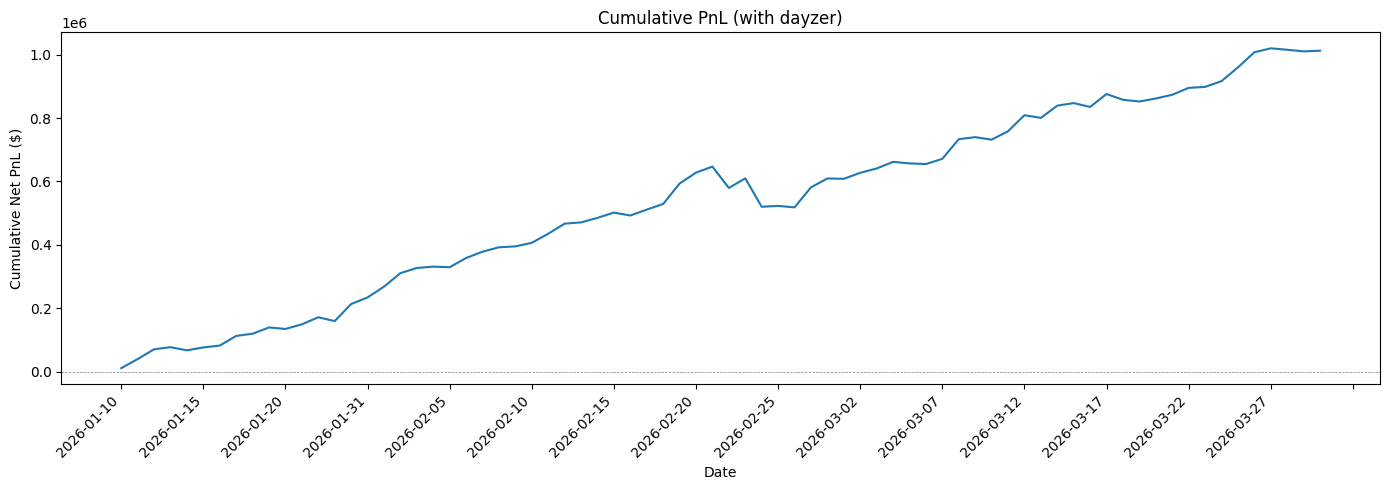

Total PnL:          $1,012,003.69
Max Daily Loss:     $-89,561.74
Profit-to-Loss:     4.76
Profit Days Total:  $1,280,837.85
Loss Days Total:    $-268,834.16
Win Rate:           75.7%


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# nogo full days
nogo_days = pd.date_range(start='2026-01-23', end='2026-01-28').strftime('%Y-%m-%d').tolist()
dayzer_re = dayzer_re[~dayzer_re['dt'].isin(nogo_days)]

# nogo specific (dt, hr) pairs
nogo_dthr = (
    [('2026-01-30', hr) for hr in range(8, 13)] +   # hr 8–12
    [('2026-01-31', hr) for hr in range(2, 12)]      # hr 2–11
)
dayzer_re['_key'] = list(zip(pd.to_datetime(dayzer_re['dt']).dt.strftime('%Y-%m-%d'), dayzer_re['hr'].astype(int)))
dayzer_re = dayzer_re[~dayzer_re['_key'].isin(nogo_dthr)].drop(columns=['_key'])


# Daily PnL
# multiply by the risk factor which is 0.65
dayzer_re['net_pnl'] = dayzer_re['net_pnl']
daily_pnl = dayzer_re.groupby('dt')['net_pnl'].sum().reset_index()
daily_pnl.columns = ['dt', 'daily_pnl']
daily_pnl['cumulative_pnl'] = daily_pnl['daily_pnl'].cumsum()

# Cumulative PnL graph
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_pnl['dt'], daily_pnl['cumulative_pnl'], linewidth=1.5)
ax.set_title('Cumulative PnL (with dayzer)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Net PnL ($)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
ax.xaxis.set_major_locator(plt.MaxNLocator(20))
plt.tight_layout()
plt.show()

# Summary stats
total_pnl = daily_pnl['daily_pnl'].sum()
profit_days = daily_pnl[daily_pnl['daily_pnl'] > 0]['daily_pnl'].sum()
loss_days = daily_pnl[daily_pnl['daily_pnl'] < 0]['daily_pnl'].sum()
max_loss = daily_pnl['daily_pnl'].min()
profit_to_loss = abs(profit_days / loss_days) if loss_days != 0 else float('inf')

print(f'Total PnL:          ${total_pnl:,.2f}')
print(f'Max Daily Loss:     ${max_loss:,.2f}')
print(f'Profit-to-Loss:     {profit_to_loss:.2f}')
print(f'Profit Days Total:  ${profit_days:,.2f}')
print(f'Loss Days Total:    ${loss_days:,.2f}')
print(f'Win Rate:           {(daily_pnl["daily_pnl"] > 0).mean():.1%}')


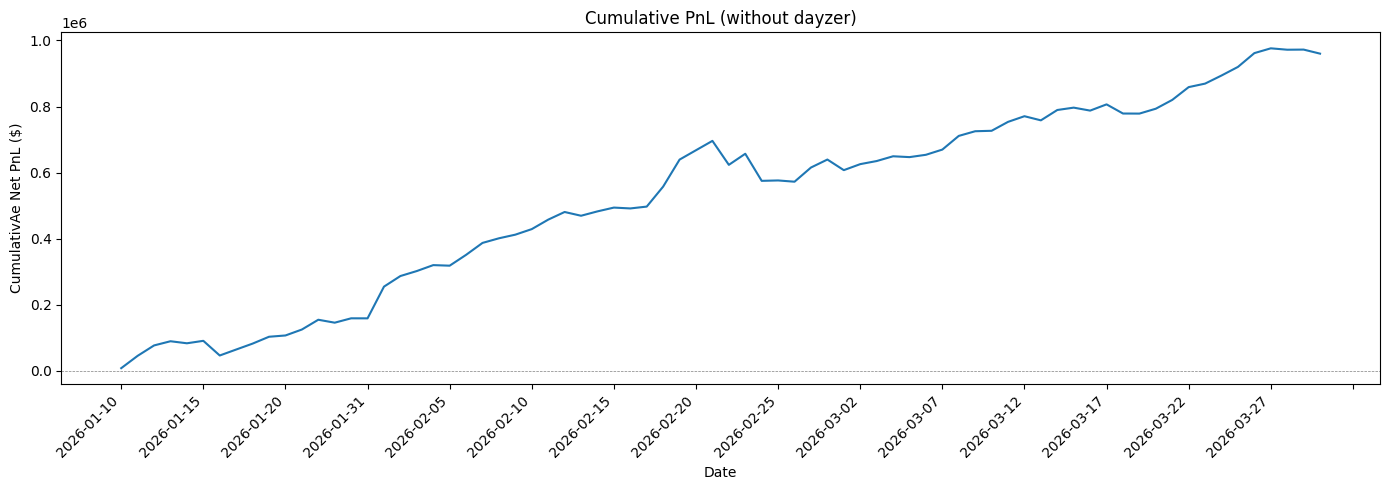

Total PnL:          $960,030.33
Max Daily Loss:     $-82,033.39
Profit-to-Loss:     3.87
Profit Days Total:  $1,294,335.27
Loss Days Total:    $-334,304.94
Win Rate:           75.7%


In [14]:
import matplotlib.pyplot as plt

date_list = pd.date_range(start='2026-01-23', end='2026-01-28').strftime('%Y-%m-%d').tolist()
dayzer_wt_re = dayzer_wt_re[~dayzer_wt_re['dt'].isin(date_list)]

# nogo specific (dt, hr) pairs
nogo_dthr = (
    [('2026-01-30', hr) for hr in range(8, 13)] +   # hr 8–12
    [('2026-01-31', hr) for hr in range(2, 12)]      # hr 2–11
)
dayzer_wt_re['_key'] = list(zip(pd.to_datetime(dayzer_wt_re['dt']).dt.strftime('%Y-%m-%d'), dayzer_wt_re['hr'].astype(int)))
dayzer_wt_re = dayzer_wt_re[~dayzer_wt_re['_key'].isin(nogo_dthr)].drop(columns=['_key'])

# Daily PnL
dayzer_wt_re['net_pnl'] = dayzer_wt_re['net_pnl']
daily_pnl2 = dayzer_wt_re.groupby('dt')['net_pnl'].sum().reset_index()
daily_pnl2.columns = ['dt', 'daily_pnl']
daily_pnl2['cumulative_pnl'] = daily_pnl2['daily_pnl'].cumsum()

# Cumulative PnL graph
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_pnl2['dt'], daily_pnl2['cumulative_pnl'], linewidth=1.5)
ax.set_title('Cumulative PnL (without dayzer)')
ax.set_xlabel('Date')
ax.set_ylabel('CumulativAe Net PnL ($)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
ax.xaxis.set_major_locator(plt.MaxNLocator(20))
plt.tight_layout()
plt.show()

# Summary stats
total_pnl = daily_pnl2['daily_pnl'].sum()
profit_days = daily_pnl2[daily_pnl2['daily_pnl'] > 0]['daily_pnl'].sum()
loss_days = daily_pnl2[daily_pnl2['daily_pnl'] < 0]['daily_pnl'].sum()
max_loss = daily_pnl2['daily_pnl'].min()
profit_to_loss = abs(profit_days / loss_days) if loss_days != 0 else float('inf')

print(f'Total PnL:          ${total_pnl:,.2f}')
print(f'Max Daily Loss:     ${max_loss:,.2f}')
print(f'Profit-to-Loss:     {profit_to_loss:.2f}')
print(f'Profit Days Total:  ${profit_days:,.2f}')
print(f'Loss Days Total:    ${loss_days:,.2f}')
print(f'Win Rate:           {(daily_pnl2["daily_pnl"] > 0).mean():.1%}')

# Check for production bids performance 

In [6]:
conn = connections.get_sql_connection(database='odessa_Bid')
df = pd.read_sql("""
    SELECT *
    FROM SPPFinalBidsBeforeAnyCut 
    WHERE strategy = 'Fourier'
      AND dt >= '2026-01-10'
      AND dt <= '2026-03-30'
    ORDER BY dt, hr, node_num, incdec
""", conn)
df['dt'] = df['dt'].astype(str)
print(f'Production bids loaded: {df.shape}')

date_list = pd.date_range(start='2026-01-23', end='2026-01-28').strftime('%Y-%m-%d').tolist()
df = df[~df['dt'].isin(date_list)]

# nogo specific (dt, hr) pairs
nogo_dthr = (
    [('2026-01-30', hr) for hr in range(8, 13)] +   # hr 8–12
    [('2026-01-31', hr) for hr in range(2, 12)]     # hr 2–11
)
df['_key'] = list(zip(pd.to_datetime(df['dt']).dt.strftime('%Y-%m-%d'), df['hr'].astype(int)))
df = df[~df['_key'].isin(nogo_dthr)].drop(columns=['_key'])
prod_run1= simulate_total_ftp(df)

Production bids loaded: (173659, 18)
2026-01-10 2026-03-30


In [20]:
prod_run1.net_pnl.sum()

np.float64(813158.0816949698)

<Axes: title={'center': 'Daily PnL Comparison'}, xlabel='dt'>

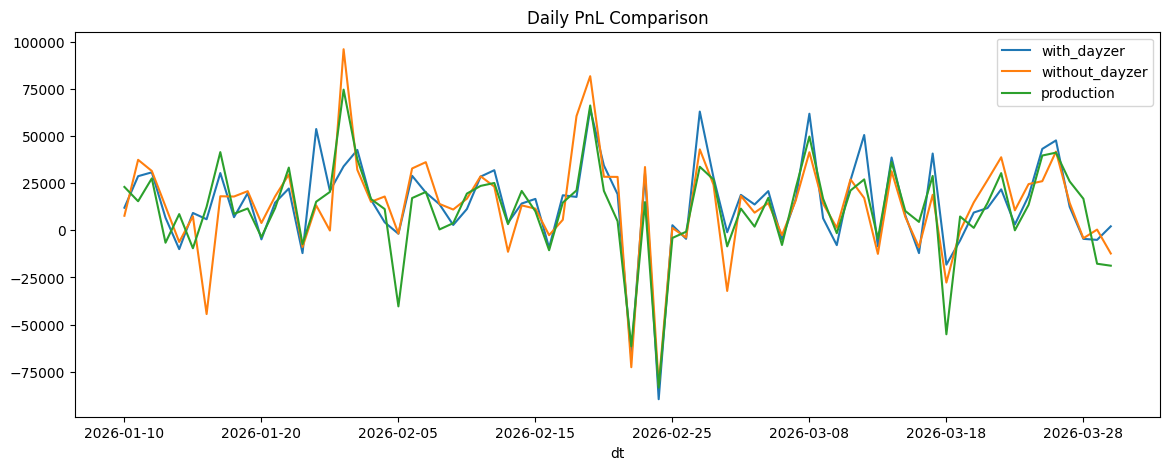

In [17]:
compare = (
    daily_pnl[['dt', 'daily_pnl']].rename(columns={'daily_pnl': 'with_dayzer'})
    .merge(daily_pnl2[['dt', 'daily_pnl']].rename(columns={'daily_pnl': 'without_dayzer'}), on='dt', how='inner')
    .merge(prod_run1.groupby('dt')['net_pnl'].sum().reset_index().rename(columns={'net_pnl': 'production'}), on='dt', how='inner')
    .sort_values('dt')
    .set_index('dt')
)
compare.plot(figsize=(14, 5), title='Daily PnL Comparison')

# Check for production prediction table

In [ ]:
from google.cloud import bigquery
import pandas as pd
bq_client = bigquery.Client()
pred = bq_client.query("""
    SELECT *
    FROM `Fourier_Production.SPP_prediction`
    WHERE run_number = 1
      AND dt >= '2026-01-10'
      AND dt <= '2026-03-30'
    ORDER BY dt, hr, node_num
""").to_dataframe()

mine= pd.read_csv('/var/www/python/Qingcheng/WFiles/sppfourier_with_dayzer.csv')


In [36]:
idx = ['dt', 'hr', 'node_num']

mine_f = mine[mine['dt'].astype(str) == '2026-02-05'][idx + ['da_total_mean', 'rt_total_mean']].copy()
mine_f['dt'] = mine_f['dt'].astype(str)
mine_f['hr'] = mine_f['hr'].astype(int)
mine_f['node_num'] = mine_f['node_num'].astype(int)

pred_f = pred[idx + ['da_total_mean', 'rt_total_mean']].copy()
pred_f['dt'] = pred_f['dt'].astype(str)
pred_f['hr'] = pred_f['hr'].astype(int)
pred_f['node_num'] = pred_f['node_num'].astype(int)

cmp = mine_f.merge(pred_f, on=idx, how='outer', suffixes=('_mine', '_prod'))

cmp['da_diff']  = cmp['da_total_mean_mine'] - cmp['da_total_mean_prod']
cmp['rt_diff']  = cmp['rt_total_mean_mine'] - cmp['rt_total_mean_prod']
cmp['da_diff_pct'] = (cmp['da_diff'] / cmp['da_total_mean_prod'].replace(0, float('nan')) * 100).round(2)
cmp['rt_diff_pct'] = (cmp['rt_diff'] / cmp['rt_total_mean_prod'].replace(0, float('nan')) * 100).round(2)

print(f'Matched rows: {cmp[["da_total_mean_mine","da_total_mean_prod"]].notna().all(axis=1).sum()} / {len(cmp)}')
print(f'\nDA mean:  mine={cmp["da_total_mean_mine"].mean():.4f}  prod={cmp["da_total_mean_prod"].mean():.4f}  diff={cmp["da_diff"].mean():.4f}')
print(f'RT mean:  mine={cmp["rt_total_mean_mine"].mean():.4f}  prod={cmp["rt_total_mean_prod"].mean():.4f}  diff={cmp["rt_diff"].mean():.4f}')
print(f'\nDA MAE: {cmp["da_diff"].abs().mean():.4f}   RT MAE: {cmp["rt_diff"].abs().mean():.4f}')

print('\nSample rows with largest DA diff:')
display(cmp.sort_values('rt_diff', key=abs, ascending=False).head(20))


Matched rows: 1752 / 1752

DA mean:  mine=17.9304  prod=17.4399  diff=0.4905
RT mean:  mine=18.5115  prod=19.9373  diff=-1.4258

DA MAE: 7.0759   RT MAE: 13.5216

Sample rows with largest DA diff:


,dt,hr,node_num,da_total_mean_mine,rt_total_mean_mine,da_total_mean_prod,rt_total_mean_prod,da_diff,rt_diff,da_diff_pct,rt_diff_pct
288,2026-02-05,4,1687,-55.681220,-143.491230,-13.965963,-44.098470,-41.715257,-99.392760,298.69,225.39
215,2026-02-05,3,1687,-46.511497,-140.374470,-6.445856,-41.319477,-40.065641,-99.054993,621.57,239.73
142,2026-02-05,2,1687,-31.197313,-139.394710,-1.198335,-43.925472,-29.998978,-95.469238,2503.39,217.34
1748,2026-02-05,24,1687,-69.121155,-123.725624,-11.402307,-30.700794,-57.718848,-93.024830,506.20,303.00
361,2026-02-05,5,1687,-53.049316,-127.427910,-16.732431,-38.432766,-36.316885,-88.995144,217.04,231.56
1632,2026-02-05,23,546,21.138592,43.503235,37.706535,130.992080,-16.567943,-87.488845,-43.94,-66.79
69,2026-02-05,1,1687,-14.912031,-119.472984,14.080683,-36.397260,-28.992714,-83.075724,-205.90,228.25
1091,2026-02-05,15,1687,-36.425423,-65.654070,-4.510313,15.784044,-31.915110,-81.438114,707.60,-515.95
1675,2026-02-05,23,1687,-58.609642,-105.250404,-6.523546,-23.975594,-52.086096,-81.274810,798.43,338.99
422,2026-02-05,6,1484,95.212980,220.328140,78.881320,140.157680,16.331660,80.170460,20.70,57.20


# Understand the training step difference

In [94]:
my_pnl = dayzer_re
prod_pnl = pd.read_csv('/var/www/python/Qingcheng/WFiles/fourier_port_pred_test.csv')
prod_pnl = simulate_total_ftp(prod_pnl)


2026-01-10 2026-03-30


In [111]:
prods = pd.DataFrame(prod_pnl.groupby(['dt'])['net_pnl'].sum())
mines = my_pnl.groupby(['dt'])['net_pnl'].sum()
finals = pd.concat([prods,mines],axis=1)
finals.columns = ['prod', 'mine']
finals['diff'] = abs(finals['prod']-finals['mine'])
finals['diff'].sort_values(ascending=False)
print(finals[finals.index=='2026-02-01'])

                    prod          mine          diff
dt                                                  
2026-02-01  73129.534551  33917.317808  39212.216743


In [130]:
fourier_port("fourier_stab_test_21", '2026-02-01','2026-02-01','fourier_stab_port_21')
fourier_temp = pd.read_csv('/var/www/python/Qingcheng/WFiles/fourier_stab_port_21.csv')
pnl_total = simulate_total_ftp(fourier_temp)
print(pnl_total.net_pnl.sum())

Running portfolio construction for 1 dates

--- 2026-02-01 ---
Getting OpRate info
Getting LMP info
Getting Reference Value info


chmod: cannot access '/var/www/python/Qingcheng/temp_test_fourier/return_and_risk/2026-02-01.csv': No such file or directory


lwg cut hours: []
  2014 bids, 6510 total MW
Cleaned up /var/www/python/Qingcheng/temp_test_fourier/

Saved (2014, 35) to /var/www/python/Qingcheng/WFiles/fourier_stab_port_21.csv
2026-02-01 2026-02-01
64193.83176706985


# Where do we make money/ Congestion or Slack / Which Zone 

In [ ]:
prod_pnl = pd.read_csv('/var/www/python/Qingcheng/WFiles/fourier_port_with_dayzer.csv')
pnl = simulate_total_ftp(prod_pnl)

2026-01-10 2026-03-30


In [49]:
# Cong pnl and slack pnl total 
date_list = pd.date_range(start='2026-01-23', end='2026-01-28').strftime('%Y-%m-%d').tolist()
pnl = pnl[~pnl['dt'].isin(date_list)]
# nogo specific (dt, hr) pairs
nogo_dthr = (
    [('2026-01-30', hr) for hr in range(8, 13)] +   # hr 8–12
    [('2026-01-31', hr) for hr in range(2, 12)]     # hr 2–11
)
pnl['_key'] = list(zip(pd.to_datetime(pnl['dt']).dt.strftime('%Y-%m-%d'), pnl['hr'].astype(int)))
pnl = pnl[~pnl['_key'].isin(nogo_dthr)].drop(columns=['_key'])
print('total congestion pnl: ', pnl.cong_pnl.sum().round(2))
print('total slack pnl:', pnl.slack_pnl.sum().round(2))
print('total net pnl', pnl.net_pnl.sum().round(2))
print('op_charge',pnl.op_rate_val.sum().round(2) )

total congestion pnl:  1088036.71
total slack pnl: 163119.93
total net pnl 1012003.69
op_charge -258087.19


In [48]:
pnl.groupby(['zone'])[['cong_pnl','slack_pnl']].sum().sort_values(by=['cong_pnl'],ascending=False).round(2)

,cong_pnl,slack_pnl
zone,,
WAUE,213756.12,57244.28
WR,211256.16,-2763.84
OKGE,145564.93,31349.65
EDE,90065.88,-13822.39
NPPD,83566.84,32775.47
OPPD,64316.50,-9479.96
WFEC,60500.27,25944.24
MPS,57647.30,5226.87
KCPL,45303.39,4190.96
